In [1]:
# Install required Python packages silently for data manipulation, visualization, machine learning, and Kaggle API access
%pip install -q kaggle pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi

# Initialize and authenticate the Kaggle API client using local credentials (~/.kaggle/kaggle.json)
api = KaggleApi()
api.authenticate()

# Specify the unique identifier for the target Kaggle competition
COMPETITION_ID = "ecom-90025-2026-sm-2-ada-assignment-and-practice"

# Display header banner for log readability
print("=" * 60)
print(f"Retrieving details for private competition: {COMPETITION_ID}")
print("=" * 60)

# Retrieve the list of dataset files available in the competition repository
print("Files available in this competition:")
files_response = api.competition_list_files(COMPETITION_ID)

# Iterate through each file entry and display its filename along with size in bytes
for file in files_response.files:
    file_size = getattr(file, 'total_bytes')
    print(f" - {file.name} ({file_size} bytes)")

print("=" * 60)

Retrieving details for private competition: ecom-90025-2026-sm-2-ada-assignment-and-practice
Files available in this competition:
 - submission.csv (11205 bytes)
 - test_data.csv (1577805 bytes)
 - train_data.csv (2413298 bytes)


In [3]:
import zipfile

# Set local directory path where data files will be downloaded and uncompressed
DESTINATION_PATH = "./week01"
print(f"Starting download for competition: {COMPETITION_ID}")

# Download the complete dataset zip bundle for the competition via Kaggle API
api.competition_download_files(competition=COMPETITION_ID, path=DESTINATION_PATH)
print("Download completed successfully.")

# Construct the file path for the downloaded ZIP archive
zip_filename = f"{COMPETITION_ID}.zip"
zip_filepath = os.path.join(DESTINATION_PATH, zip_filename)

# Extract all contents from the ZIP archive into the target folder
print("Extracting files...")
with zipfile.ZipFile(zip_filepath, 'r') as zip_ref:
    zip_ref.extractall(DESTINATION_PATH)
            
# Remove the temporary ZIP archive to free disk space and clean up the workspace
os.remove(zip_filepath)
print(f"Files extracted successfully to '{DESTINATION_PATH}' directory.")

Starting download for competition: ecom-90025-2026-sm-2-ada-assignment-and-practice
Download completed successfully.
Extracting files...
Files extracted successfully to './week01' directory.


In [4]:
# Import core data handling and visualization packages
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Load the training dataset from the extracted CSV file into a pandas DataFrame
train_df = pd.read_csv("./week01/train_data.csv")

# Output the dimensions (number of rows and columns) of the training dataset
print(f"Dataset shape: {train_df.shape}\n")

# Display concise summary of dataset structure including column data types and non-null counts
print("--- Info ---")
train_df.info()

# Generate and display descriptive summary statistics (mean, std, min, max, quantiles) for numerical features
print("\n--- Summary Statistics ---")
print(train_df.describe())

# Display the first 5 rows of the dataset for an initial visual inspection of the raw data values
print("\n--- Preview (First 5 Rows) ---")
print(train_df.head())

Dataset shape: (2400, 52)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 52 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Y       2400 non-null   float64
 1   X1      2400 non-null   float64
 2   X2      2400 non-null   float64
 3   X3      2400 non-null   float64
 4   X4      2400 non-null   float64
 5   X5      2400 non-null   float64
 6   X6      2400 non-null   float64
 7   X7      2400 non-null   float64
 8   X8      2400 non-null   float64
 9   X9      2400 non-null   float64
 10  X10     2400 non-null   float64
 11  X11     2400 non-null   float64
 12  X12     2400 non-null   float64
 13  X13     2400 non-null   float64
 14  X14     2400 non-null   float64
 15  X15     2400 non-null   float64
 16  X16     2400 non-null   float64
 17  X17     2400 non-null   float64
 18  X18     2400 non-null   float64
 19  X19     2400 non-null   float64
 20  X20     2400 non-null   float64
 2

In [6]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.linear_model import Lasso, LinearRegression, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [7]:
import os
output_dir = "./week01/outputs"
os.makedirs(output_dir, exist_ok=True)

# plotly needs kaleido to export static images
%pip install -q kaleido

Note: you may need to restart the kernel to use updated packages.


In [8]:
# ==========================================
#linear part
# Step 1: Data — load training data
# ==========================================
train_df = pd.read_csv("./week01/train_data.csv")

target_col = 'Y'
feature_cols = [f"X{i}" for i in range(1, 51) if f"X{i}" in train_df.columns]

X0 = train_df[feature_cols]
y0 = train_df[target_col]

print(f"Dataset shape: {train_df.shape}")
print(f"Number of candidate variables: {len(feature_cols)}")

Dataset shape: (2400, 52)
Number of candidate variables: 50


In [9]:
# ==========================================
# Step 2: LASSO — scale first (as in Week04 course notebook)
# ==========================================
scaler = StandardScaler()
X1 = scaler.fit_transform(X0)

# Quick illustrative fit (as done in the course notebook, alpha=0.01)
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X1, y0)

print(f"Number of non-zero coefficients: {np.sum(lasso_model.coef_ != 0)}")

coeff_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': lasso_model.coef_})

fig = px.scatter(coeff_df, x='Feature', y='Coefficient',
                  title='Lasso Regression Coefficients ',
                  labels={'Coefficient': 'Coefficient Value'})
fig.update_layout(xaxis={'tickangle': -45, 'title': 'Feature'},
                   yaxis={'title': 'Coefficient'},
                   showlegend=False)
fig.write_image(f"{output_dir}/linear_lasso_coefficients.png", width=1200, height=600, scale=2)
fig.show()

Number of non-zero coefficients: 47


In [10]:
# ==========================================
# Step 3: Model selection via AICc
# ==========================================
alphas = np.logspace(-5, 1, num=100)

aiccs = []
for alpha in alphas:
    lasso_temp = Lasso(alpha=alpha, max_iter=10000)
    lasso_temp.fit(X1, y0)
    mse = mean_squared_error(y0, lasso_temp.predict(X1))
    n = len(y0)
    num_params = np.count_nonzero(lasso_temp.coef_) + 1  # +1 for intercept
    aicc = n * np.log(mse) + 2 * num_params + 2 * num_params * (num_params + 1) / (n - num_params - 1)
    aiccs.append(aicc)

best_alpha_aicc = alphas[np.argmin(aiccs)]
print(f"Best alpha (AICc): {best_alpha_aicc}")

fig = px.scatter(x=alphas, y=aiccs, log_x=True,
                  title='AICc vs Alpha (Penalty Term)',
                  labels={'x': 'Alpha (Penalty Term)', 'y': 'AICc'})

fig.write_image(f"{output_dir}/linear_aicc_vs_alpha.png", width=1000, height=600, scale=2)
fig.show()

Best alpha (AICc): 0.03274549162877728


In [11]:
# ==========================================
# Step 4: Variable Selection — refit Lasso using the AICc-selected alpha
# ==========================================
lasso_aicc = Lasso(alpha=best_alpha_aicc, max_iter=10000).fit(X1, y0)

aicc_selected = [f for f, c in zip(feature_cols, lasso_aicc.coef_) if c != 0]

print(f"AICc selected {len(aicc_selected)} features: {aicc_selected}")

final_selected = aicc_selected

AICc selected 38 features: ['X1', 'X2', 'X3', 'X5', 'X6', 'X7', 'X9', 'X10', 'X11', 'X12', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X26', 'X27', 'X29', 'X30', 'X31', 'X32', 'X34', 'X35', 'X39', 'X40', 'X41', 'X42', 'X43', 'X45', 'X46', 'X47', 'X48']


In [12]:
# ==========================================
# Step 5: Final Model — refit OLS on the selected variables
# ==========================================
X_final = train_df[final_selected]
final_model = LinearRegression()
final_model.fit(X_final, y0)

r2_final = final_model.score(X_final, y0)

print("--- Final Multiple Regression Results ---")
for feat, coef in zip(final_selected, final_model.coef_):
    print(f"{feat:10s}: {coef:.4f}")
print(f"Intercept : {final_model.intercept_:.4f}")
print(f"R-squared : {r2_final:.4f}")

--- Final Multiple Regression Results ---
X1        : 0.2625
X2        : 0.0271
X3        : 0.0185
X5        : 0.4909
X6        : 0.0462
X7        : -0.1265
X9        : -0.1413
X10       : 0.2987
X11       : 0.0316
X12       : 0.3228
X14       : 0.1437
X15       : 0.2870
X16       : 0.3919
X17       : 0.1175
X18       : 0.0886
X19       : 0.1806
X20       : 0.1900
X21       : 0.5016
X22       : 0.2559
X23       : 0.4358
X24       : 0.0864
X26       : 0.3734
X27       : -0.6051
X29       : 0.0465
X30       : 0.2780
X31       : -0.1351
X32       : 0.0805
X34       : 0.9102
X35       : 0.5156
X39       : 0.4189
X40       : 0.0836
X41       : 0.2796
X42       : 0.3504
X43       : 0.0768
X45       : 0.5998
X46       : 0.4649
X47       : 0.0190
X48       : -1.4237
Intercept : -6.1893
R-squared : 0.5896


In [13]:
# ==========================================
# Step 6: OVB Diagnostic — X34 coefficient, Assignment 1 vs Assignment 2
# ==========================================
single_model = LinearRegression().fit(train_df[['X34']], y0)
beta1_single = single_model.coef_[0]

if 'X34' in final_selected:
    idx = final_selected.index('X34')
    beta1_multi = final_model.coef_[idx]
    change_pct = (beta1_multi - beta1_single) / beta1_single * 100
    print("--- OVB Diagnostic: Coefficient on X34 ---")
    print(f"Single-variable model (Assignment 1): beta_1 = {beta1_single:.4f}")
    print(f"Multiple regression model (Assignment 2): beta_1 = {beta1_multi:.4f}")
    print(f"Change: {change_pct:.1f}%")
else:
    print("X34 was not retained in the final model.")

--- OVB Diagnostic: Coefficient on X34 ---
Single-variable model (Assignment 1): beta_1 = 2.0492
Multiple regression model (Assignment 2): beta_1 = 0.9102
Change: -55.6%


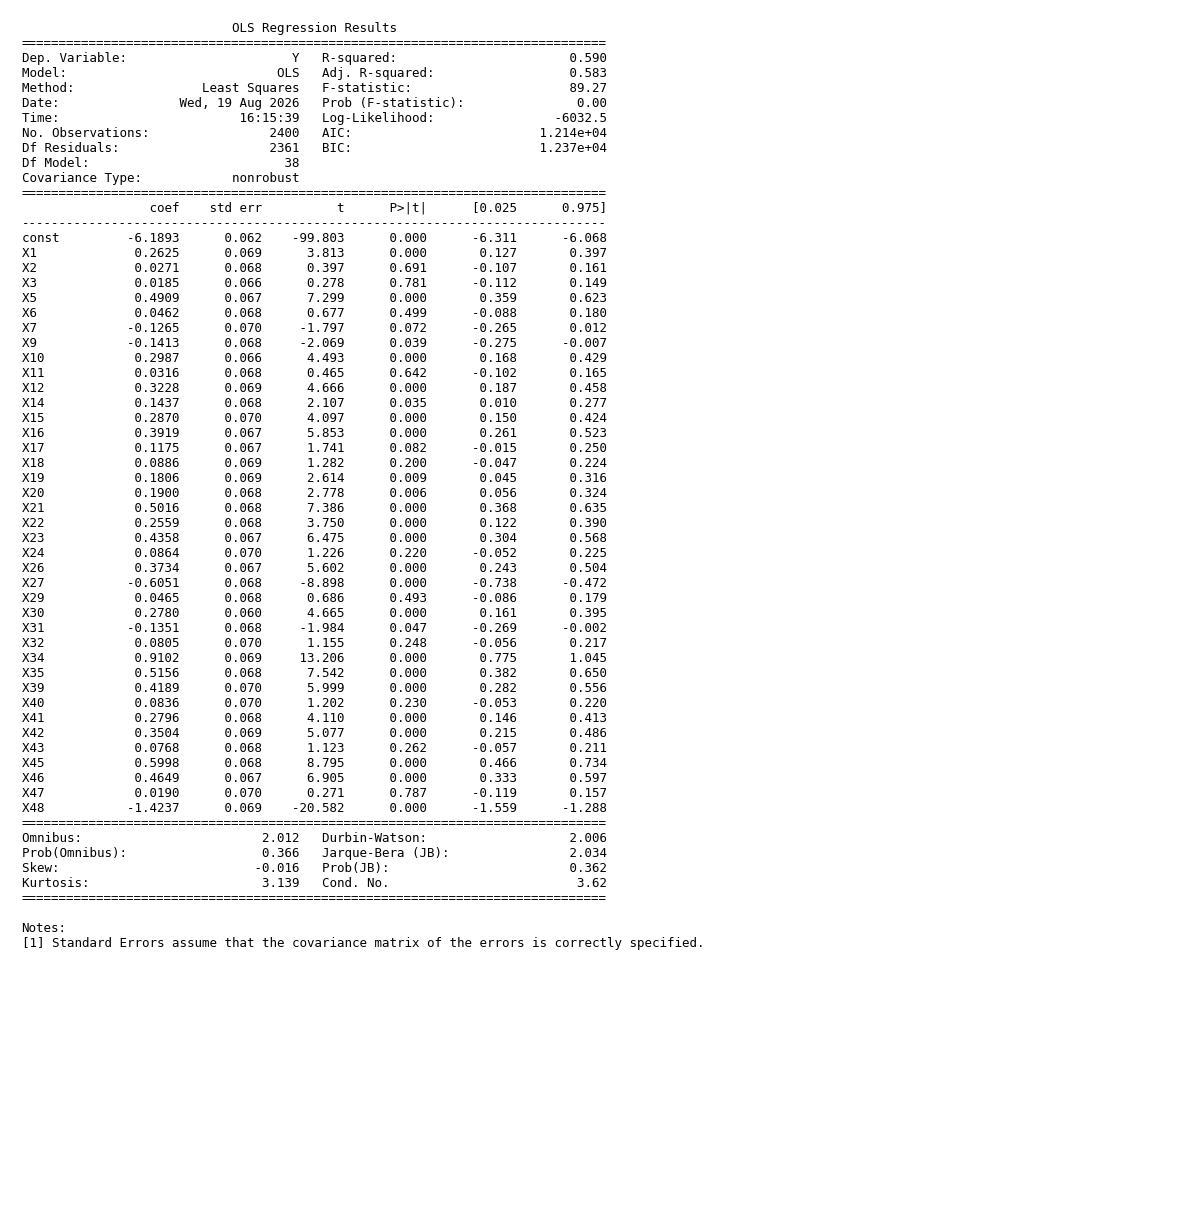

In [14]:
# ==================================================
# Step 7: Export the OLS summary as a PNG image
# ==================================================

import statsmodels.api as sm
import matplotlib.pyplot as plt

# Estimate the post-LASSO OLS model
X_final_with_const = sm.add_constant(
    train_df[final_selected]
)

ols_summary_final = sm.OLS(
    y0,
    X_final_with_const
).fit()

# Convert OLS results to text
summary_text = ols_summary_final.summary().as_text()

# Automatically adjust image height
number_of_lines = len(summary_text.splitlines())
figure_height = max(8, number_of_lines * 0.25)

# Create image
fig, ax = plt.subplots(figsize=(15, figure_height))

ax.text(
    0.01,
    0.99,
    summary_text,
    transform=ax.transAxes,
    fontsize=9,
    fontfamily="monospace",
    verticalalignment="top",
    horizontalalignment="left"
)

ax.axis("off")

# Save only as PNG
plt.savefig(
    f"{output_dir}/linear_model_summary.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.3,
    facecolor="white"
)

plt.show()

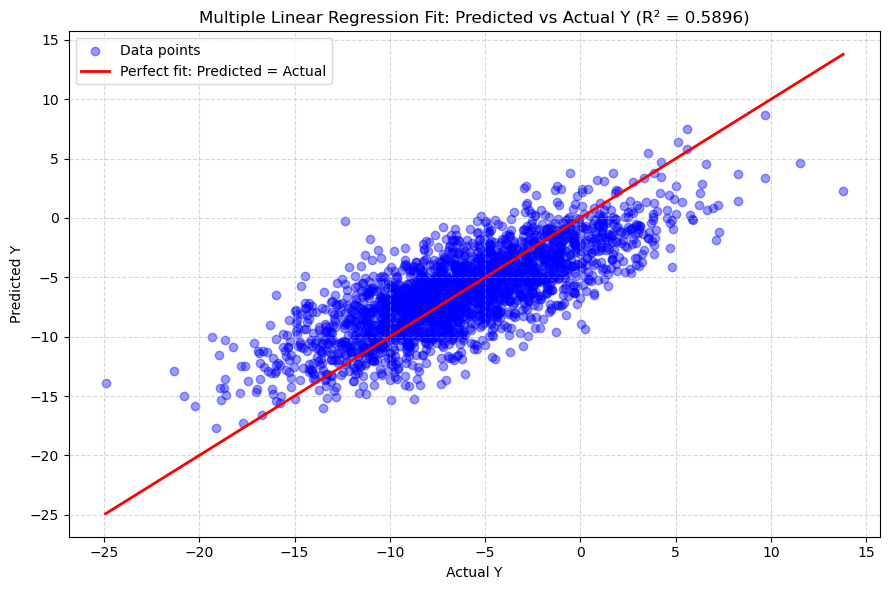

In [15]:
# ==========================================
# Step 7: Predicted vs Actual scatter plot with 45-degree reference line
# (multiple regression equivalent of the Assignment 1 style plot)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

train_df['Y_pred_train'] = final_model.predict(X_final)

plt.figure(figsize=(9, 6))
plt.scatter(y0, train_df['Y_pred_train'], alpha=0.4, color='blue', label='Data points')

line_vals = np.linspace(y0.min(), y0.max(), 100)
plt.plot(line_vals, line_vals, color='red', linewidth=2, label='Perfect fit: Predicted = Actual')

plt.xlabel('Actual Y')
plt.ylabel('Predicted Y')
plt.title(f'Multiple Linear Regression Fit: Predicted vs Actual Y (R² = {r2_final:.4f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [16]:
# ==========================================
# quadratic model
# Step 1: Construct quadratic candidate pool (all variables squared)
# ==========================================
train_df_quad = train_df.copy()

quad_cols = []
for var in feature_cols:
    new_col = f"{var}_sq"
    train_df_quad[new_col] = train_df_quad[var] ** 2
    quad_cols.append(new_col)

# Full candidate pool = 50 original + 50 quadratic terms
extended_feature_cols = feature_cols + quad_cols

X0_quad = train_df_quad[extended_feature_cols]
y0 = train_df_quad[target_col]

print(f"Total candidate variables (original + squared): {len(extended_feature_cols)}")

Total candidate variables (original + squared): 100


In [17]:
# ==========================================
# Step 2: LASSO on quadratic candidate pool — scale first
# ==========================================
scaler_quad = StandardScaler()
X1_quad = scaler_quad.fit_transform(X0_quad)

lasso_model_quad = Lasso(alpha=0.01)
lasso_model_quad.fit(X1_quad, y0)

print(f"Number of non-zero coefficients: {np.sum(lasso_model_quad.coef_ != 0)}")

coeff_df_quad = pd.DataFrame({'Feature': extended_feature_cols, 'Coefficient': lasso_model_quad.coef_})

fig = px.scatter(coeff_df_quad, x='Feature', y='Coefficient',
                  title='Lasso Regression Coefficients — Quadratic Model',
                  labels={'Coefficient': 'Coefficient Value'})
fig.update_layout(xaxis={'tickangle': -45, 'title': 'Feature'},
                   yaxis={'title': 'Coefficient'},
                   showlegend=False)
fig.write_image(f"{output_dir}/quadratic_lasso_coefficients.png", width=1200, height=600, scale=2)
fig.show()

Number of non-zero coefficients: 90


In [18]:
# ==========================================
# Step 3: Model selection via AICc — Quadratic Model
# ==========================================
alphas_quad = np.logspace(-5, 1, num=100)

aiccs_quad = []
for alpha in alphas_quad:
    lasso_temp = Lasso(alpha=alpha, max_iter=10000)
    lasso_temp.fit(X1_quad, y0)
    mse = mean_squared_error(y0, lasso_temp.predict(X1_quad))
    n = len(y0)
    num_params = np.count_nonzero(lasso_temp.coef_) + 1
    aicc = n * np.log(mse) + 2 * num_params + 2 * num_params * (num_params + 1) / (n - num_params - 1)
    aiccs_quad.append(aicc)

best_alpha_aicc_quad = alphas_quad[np.argmin(aiccs_quad)]
print(f"Best alpha (AICc, Quadratic Model): {best_alpha_aicc_quad}")

fig = px.scatter(x=alphas_quad, y=aiccs_quad, log_x=True,
                  title='AICc vs Alpha — Quadratic Model',
                  labels={'x': 'Alpha (Penalty Term)', 'y': 'AICc'})
fig.write_image(f"{output_dir}/quadratic_aicc_vs_alpha.png", width=1000, height=600, scale=2)
fig.show()

Best alpha (AICc, Quadratic Model): 0.03274549162877728


In [19]:
# ==========================================
# Step 4: Variable Selection — refit Lasso using the AICc-selected alpha
# ==========================================
lasso_aicc_quad = Lasso(alpha=best_alpha_aicc_quad, max_iter=10000).fit(X1_quad, y0)

quad_selected = [f for f, c in zip(extended_feature_cols, lasso_aicc_quad.coef_) if c != 0]

print(f"AICc selected {len(quad_selected)} features (Quadratic Model): {quad_selected}")

AICc selected 74 features (Quadratic Model): ['X1', 'X2', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X26', 'X27', 'X30', 'X31', 'X32', 'X34', 'X35', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48', 'X1_sq', 'X2_sq', 'X4_sq', 'X7_sq', 'X8_sq', 'X9_sq', 'X11_sq', 'X12_sq', 'X13_sq', 'X15_sq', 'X16_sq', 'X17_sq', 'X18_sq', 'X19_sq', 'X20_sq', 'X21_sq', 'X22_sq', 'X25_sq', 'X26_sq', 'X27_sq', 'X29_sq', 'X31_sq', 'X32_sq', 'X33_sq', 'X34_sq', 'X35_sq', 'X36_sq', 'X38_sq', 'X39_sq', 'X40_sq', 'X41_sq', 'X42_sq', 'X43_sq', 'X44_sq', 'X45_sq', 'X49_sq']


In [20]:
# ==========================================
# Step 5: Final Model — refit OLS on the selected quadratic variables
# ==========================================
X_final_quad = train_df_quad[quad_selected]
final_model_quad = LinearRegression()
final_model_quad.fit(X_final_quad, y0)

r2_final_quad = final_model_quad.score(X_final_quad, y0)

print("--- Final Multiple Regression Results (Quadratic Model) ---")
for feat, coef in zip(quad_selected, final_model_quad.coef_):
    print(f"{feat:12s}: {coef:.4f}")
print(f"Intercept : {final_model_quad.intercept_:.4f}")
print(f"R-squared : {r2_final_quad:.4f}")

--- Final Multiple Regression Results (Quadratic Model) ---
X1          : 0.2384
X2          : 0.0272
X5          : 0.5016
X6          : 0.0619
X7          : -0.1008
X8          : 0.0145
X9          : -0.1464
X10         : 0.2799
X11         : 0.0215
X12         : 0.3787
X14         : 0.1577
X15         : 0.3015
X16         : 0.4272
X17         : 0.1352
X18         : 0.0399
X19         : 0.1517
X20         : 0.2239
X21         : 0.4685
X22         : 0.2427
X23         : 0.4403
X24         : 0.0608
X26         : 0.3553
X27         : -0.6083
X30         : 0.2942
X31         : -0.1101
X32         : 0.0977
X34         : 0.9161
X35         : 0.4727
X39         : 0.4427
X40         : 0.0484
X41         : 0.2720
X42         : 0.3392
X43         : 0.0817
X44         : -0.0601
X45         : 0.6427
X46         : 0.4908
X47         : 0.0457
X48         : -1.4116
X1_sq       : -0.0314
X2_sq       : -0.0254
X4_sq       : 0.0848
X7_sq       : -0.0616
X8_sq       : -0.0537
X9_sq       : -0.4195
X11_s

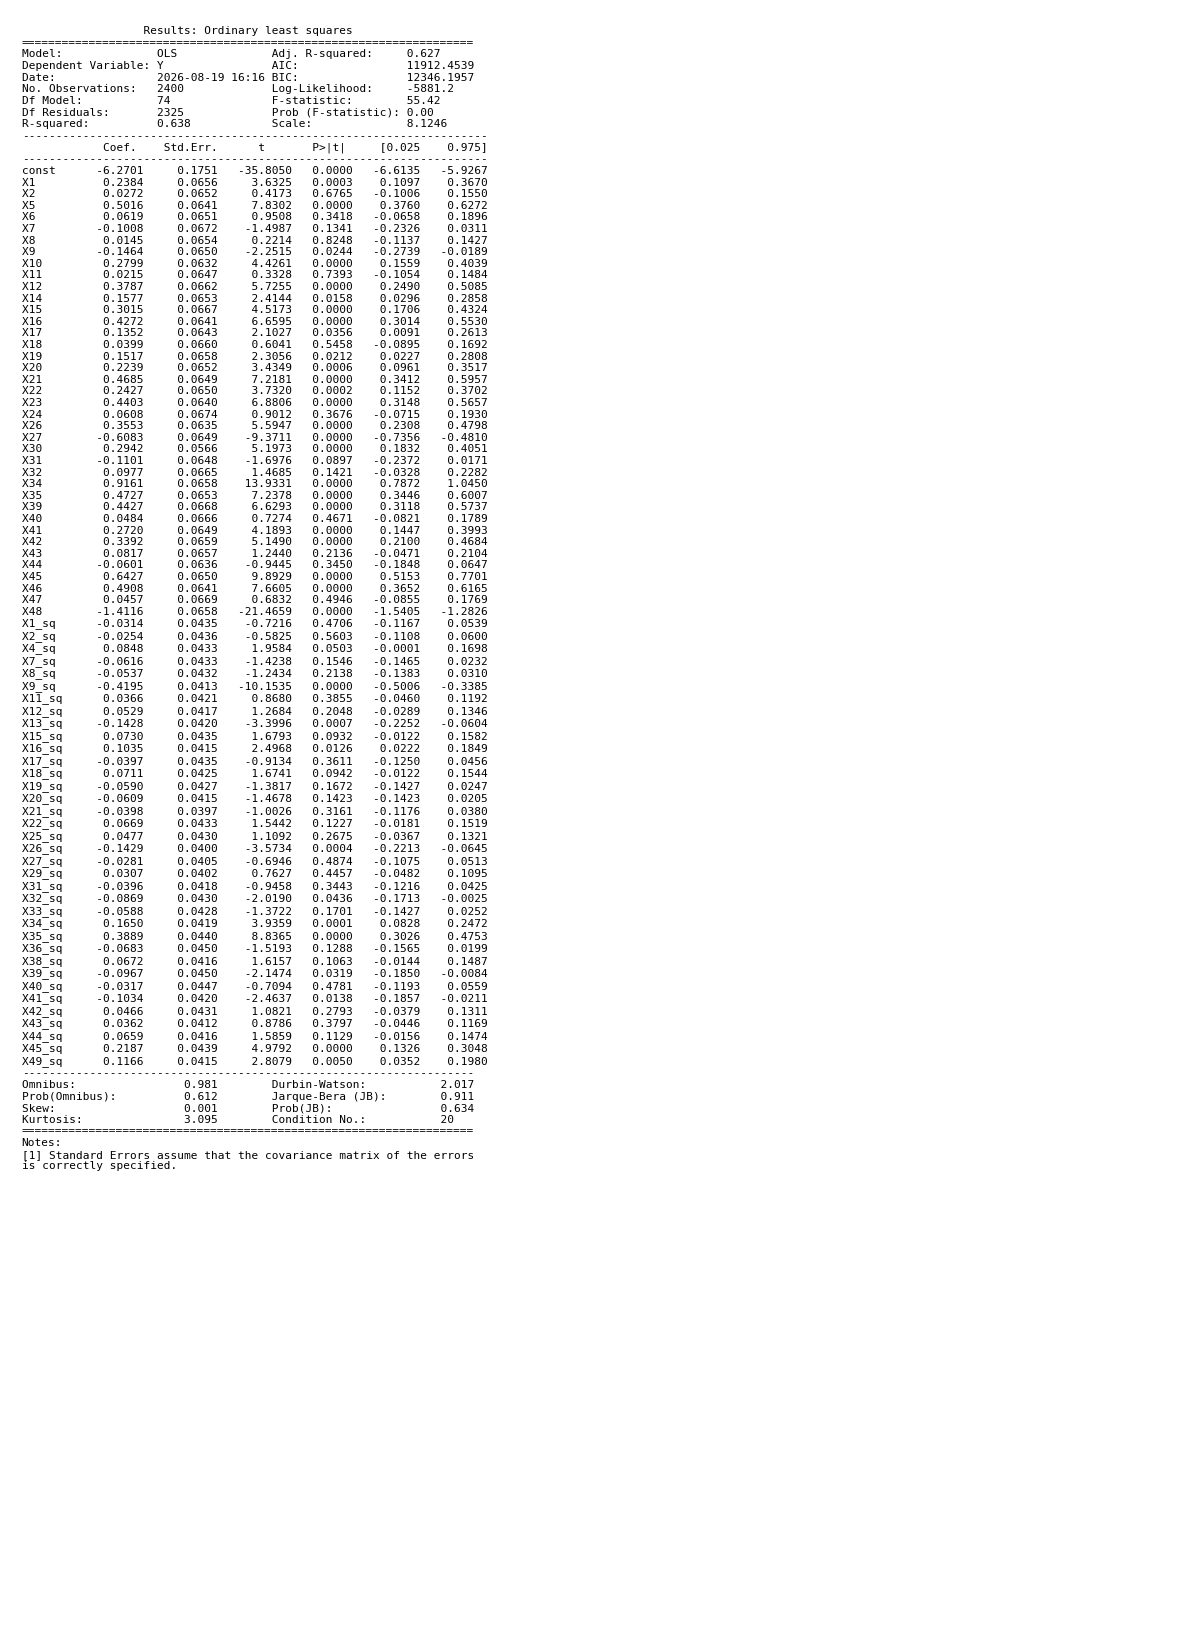

In [21]:
# ==================================================
# Step 6: Export the Quadratic Model summary as PNG
# ==================================================

import statsmodels.api as sm
import matplotlib.pyplot as plt

# Estimate the post-LASSO quadratic OLS model
X_final_quad_with_const = sm.add_constant(
    train_df_quad[quad_selected]
)

ols_summary_quad = sm.OLS(
    y0,
    X_final_quad_with_const
).fit()

# Convert the complete regression output to text
summary_text_quad = ols_summary_quad.summary2().as_text()

# Automatically adjust the image height
number_of_lines = len(summary_text_quad.splitlines())
figure_height = max(10, number_of_lines * 0.22)

# Create the image
fig, ax = plt.subplots(
    figsize=(15, figure_height)
)

ax.text(
    0.01,
    0.99,
    summary_text_quad,
    transform=ax.transAxes,
    fontsize=8,
    fontfamily="monospace",
    verticalalignment="top",
    horizontalalignment="left"
)

ax.axis("off")

# Save only as a PNG image
plt.savefig(
    f"{output_dir}/quadratic_model_summary.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.3,
    facecolor="white"
)

plt.show()

In [22]:
# ==========================================
# Step 7: Compare Linear Model vs Quadratic Model
# ==========================================
print("--- Model Comparison ---")
print(f"Linear Model    (Assignment 2, {len(final_selected)} vars): R² = {r2_final:.4f}")
print(f"Quadratic Model ({len(quad_selected)} vars): R² = {r2_final_quad:.4f}")

improvement = (r2_final_quad - r2_final) / r2_final * 100
print(f"Improvement: {improvement:.1f}%")

# Check which variables retained a squared term (evidence of non-linearity)
sq_retained = [f for f in quad_selected if f.endswith('_sq')]
print(f"\nVariables with retained quadratic terms: {sq_retained}")

--- Model Comparison ---
Linear Model    (Assignment 2, 38 vars): R² = 0.5896
Quadratic Model (74 vars): R² = 0.6382
Improvement: 8.2%

Variables with retained quadratic terms: ['X1_sq', 'X2_sq', 'X4_sq', 'X7_sq', 'X8_sq', 'X9_sq', 'X11_sq', 'X12_sq', 'X13_sq', 'X15_sq', 'X16_sq', 'X17_sq', 'X18_sq', 'X19_sq', 'X20_sq', 'X21_sq', 'X22_sq', 'X25_sq', 'X26_sq', 'X27_sq', 'X29_sq', 'X31_sq', 'X32_sq', 'X33_sq', 'X34_sq', 'X35_sq', 'X36_sq', 'X38_sq', 'X39_sq', 'X40_sq', 'X41_sq', 'X42_sq', 'X43_sq', 'X44_sq', 'X45_sq', 'X49_sq']


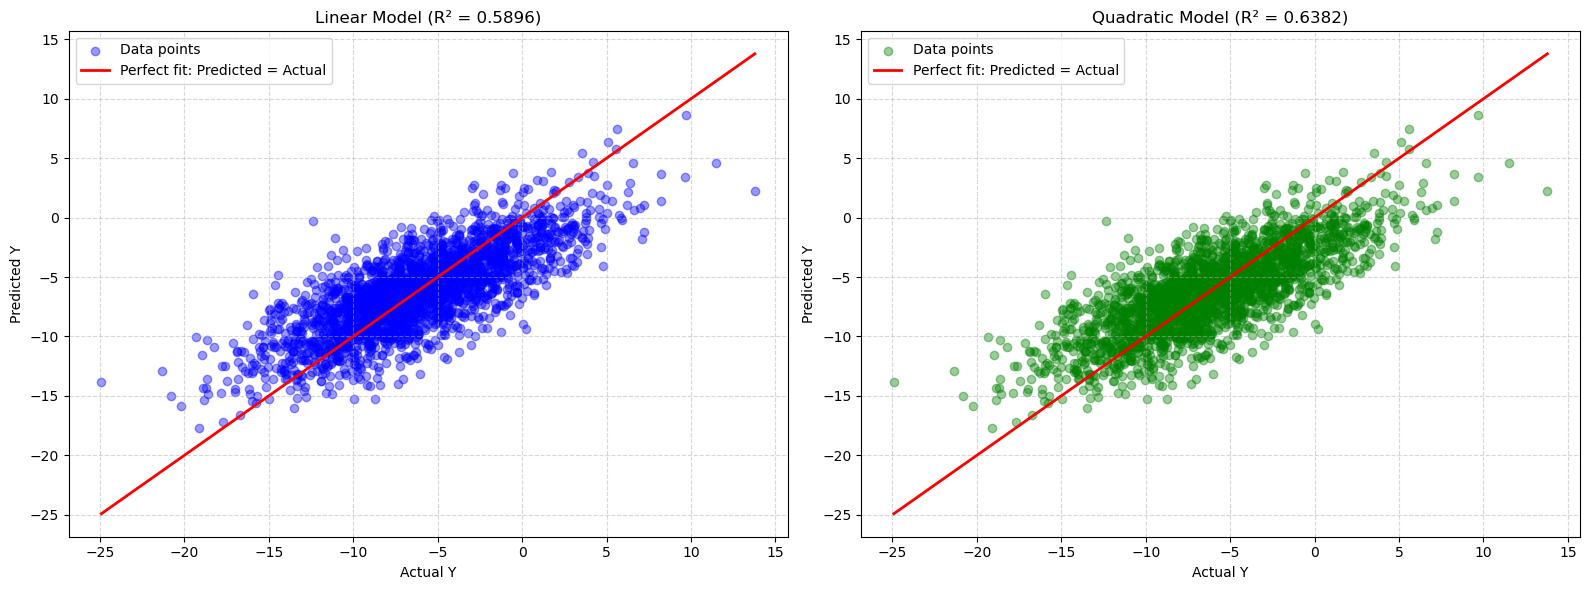

In [23]:
# ==========================================
# Side-by-side comparison: Linear Model vs Quadratic Model
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear Model (left)
axes[0].scatter(y0, train_df['Y_pred_train'], alpha=0.4, color='blue', label='Data points')
axes[0].plot(line_vals, line_vals, color='red', linewidth=2, label='Perfect fit: Predicted = Actual')
axes[0].set_xlabel('Actual Y')
axes[0].set_ylabel('Predicted Y')
axes[0].set_title(f'Linear Model (R² = {r2_final:.4f})')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Quadratic Model (right)
axes[1].scatter(y0, train_df_quad['Y_pred_train'], alpha=0.4, color='green', label='Data points')
axes[1].plot(line_vals, line_vals, color='red', linewidth=2, label='Perfect fit: Predicted = Actual')
axes[1].set_xlabel('Actual Y')
axes[1].set_ylabel('Predicted Y')
axes[1].set_title(f'Quadratic Model (R² = {r2_final_quad:.4f})')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f"{output_dir}/linear_vs_quadratic_comparison.png", dpi=200, bbox_inches='tight')
plt.show()

In [24]:
# ==========================================
# Load Testing Set & Generate Predictions (Quadratic Model)
# ==========================================

# Load the test dataset
test_df = pd.read_csv("./week01/test_data.csv")

# Recreate the same squared feature engineering used for the training set
test_df_quad = test_df.copy()
for var in feature_cols:
    test_df_quad[f"{var}_sq"] = test_df_quad[var] ** 2

# Select only the variables retained by the quadratic model (quad_selected)
X_test_quad = test_df_quad[quad_selected]

# Generate predictions using the final quadratic model
test_df_quad["Y_pred"] = final_model_quad.predict(X_test_quad)

# Display a preview of the predictions alongside the ID column
print("Preview of test predictions:")
print(test_df_quad[["ID", "Y_pred"]].head())

Preview of test predictions:
     ID    Y_pred
0  2400 -7.095025
1  2401 -2.415793
2  2402 -5.660484
3  2403 -7.958129
4  2404 -9.528054


In [25]:
# ==========================================
# Generate Submission File
# ==========================================

# Create a submission DataFrame with 'ID' and predicted 'Y'
submission_df = pd.DataFrame({
    "ID": test_df["ID"],
    "Y": test_df_quad["Y_pred"]
})

# Save the submission file to the week01 folder
output_path = "./week01/my_submission.csv"
submission_df.to_csv(output_path, index=False)

print(f"Submission file generated at: {output_path}")
print("\nFirst 5 rows of the submission:")
print(submission_df.head())

Submission file generated at: ./week01/my_submission.csv

First 5 rows of the submission:
     ID         Y
0  2400 -7.095025
1  2401 -2.415793
2  2402 -5.660484
3  2403 -7.958129
4  2404 -9.528054


In [128]:
# ==========================================
# Submit to Kaggle
# ==========================================

# Submit predictions to the Kaggle competition leaderboard
print("Submitting predictions to Kaggle...")
api.competition_submit(
    file_name="./week01/my_submission.csv",
    message="Quadratic LASSO-AICc selected multiple regression submission",
    competition=COMPETITION_ID
)
print("Submission successful!")

Submitting predictions to Kaggle...


100%|██████████| 37.9k/37.9k [00:00<00:00, 41.9kB/s]


HTTPError: 400 Client Error: Bad Request for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/CreateSubmission